# Model 2: EfficientNetB4 Testing and Grad-CAM Explainability

This notebook loads the final trained EfficientNetB4 model for waste material classification and tests it on external sample images.

It also applies Grad-CAM explainability to visualize the image regions that influenced the model predictions. Grad-CAM was used for experimental analysis only and was not integrated as a user-facing feature in the mobile application.

imports

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

load saved model

In [ ]:
# model = tf.keras.models.load_model(
#     "waste_classifier_effnetB4_final.keras"
# )


In [2]:
drive.mount('/content/drive')

model_path = "/content/drive/MyDrive/grad project models/waste_classifier_effnetB4_final.keras"
model = tf.keras.models.load_model(model_path)

print("Model loaded")

Mounted at /content/drive
Model loaded


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 226 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


define class names

In [3]:
class_names = [
    'E-waste',
    'automobile wastes',
    'battery waste',
    'glass waste',
    'light bulbs',
    'metal waste',
    'organic waste',
    'paper waste',
    'plastic waste'
]


Prediction Function

In [4]:
def predict_image(img_path):
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(380, 380)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    preds = model.predict(img_array)
    class_id = np.argmax(preds[0])
    confidence = np.max(preds[0])

    print("Predicted class:", class_names[class_id])
    print("Confidence:", confidence)

    plt.imshow(img)
    plt.axis("off")
    plt.show()


test sample images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
Predicted class: plastic waste
Confidence: 0.9887701


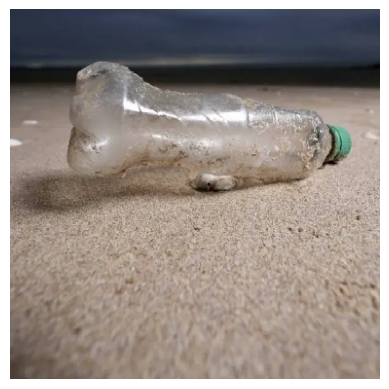

In [11]:
predict_image("/content/plasticcwaste.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predicted class: metal waste
Confidence: 0.40938655


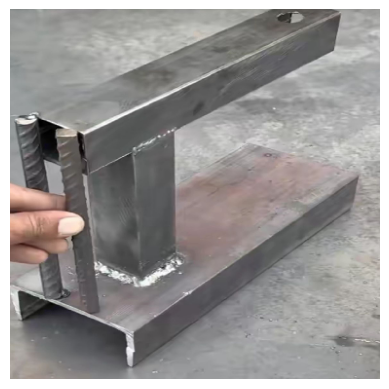

In [ ]:
predict_image("/content/sampemetal.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted class: organic waste
Confidence: 0.7097304


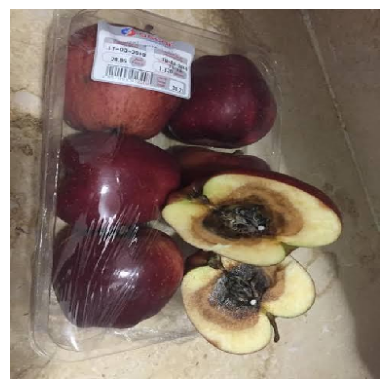

In [ ]:
predict_image("/content/sampleorganic.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted class: paper waste
Confidence: 0.9991698


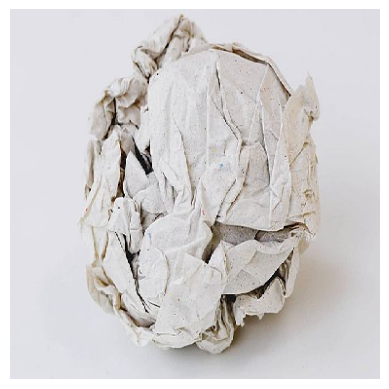

In [ ]:
predict_image("/content/samplepaper.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted class: glass waste
Confidence: 0.55984193


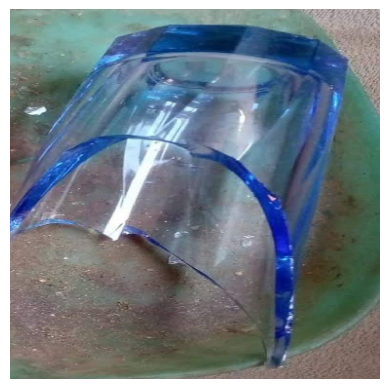

In [ ]:
predict_image("/content/sampleglass.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted class: battery waste
Confidence: 0.865386


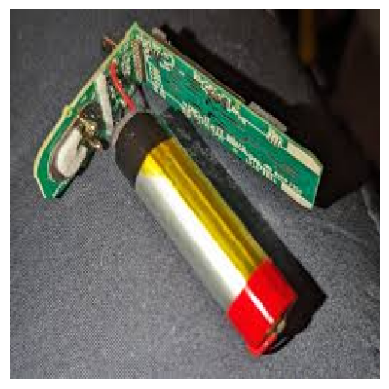

In [ ]:
predict_image("/content/samplebattery.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted class: E-waste
Confidence: 0.7785416


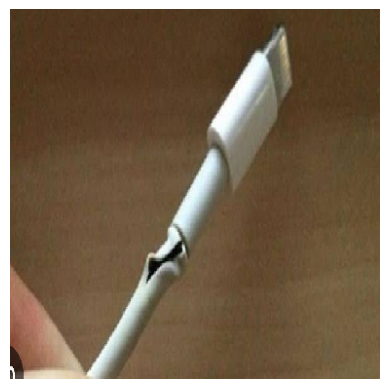

In [ ]:
predict_image("/content/sampleewaste.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Predicted class: automobile wastes
Confidence: 0.9864182


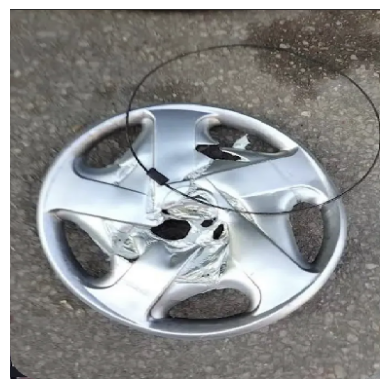

In [7]:
predict_image('/content/automobileewaste.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Predicted class: light bulbs
Confidence: 0.9534129


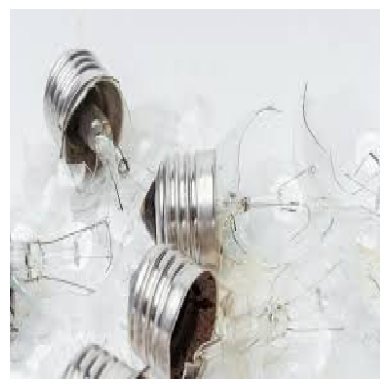

In [ ]:
predict_image('/content/samplelightbulb.jpeg')

Grad-cam explanation

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def gradcam_final(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(380, 380))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    aug = model.get_layer("sequential")
    efficientnet = model.get_layer("efficientnetb4")
    gap = model.get_layer("global_average_pooling2d_1")
    dropout = model.get_layer("dropout_1")
    dense = model.get_layer("dense_1")

    with tf.GradientTape() as tape:
        x = aug(img_array, training=False)
        conv_outputs = efficientnet(x, training=False)

        x = gap(conv_outputs)
        x = dropout(x, training=False)
        predictions = dense(x)

        class_index = int(np.argmax(predictions.numpy()[0]))
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    confidence = np.max(predictions.numpy()[0])

    print("Predicted class:", class_names[class_index])
    print("Confidence:", confidence)

    original = np.array(img).astype(np.uint8)

    heatmap = cv2.resize(heatmap, (380, 380))

    heatmap_uint8 = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Explanation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

apply GRAD-CAM

Predicted class: plastic waste
Confidence: 0.9887701


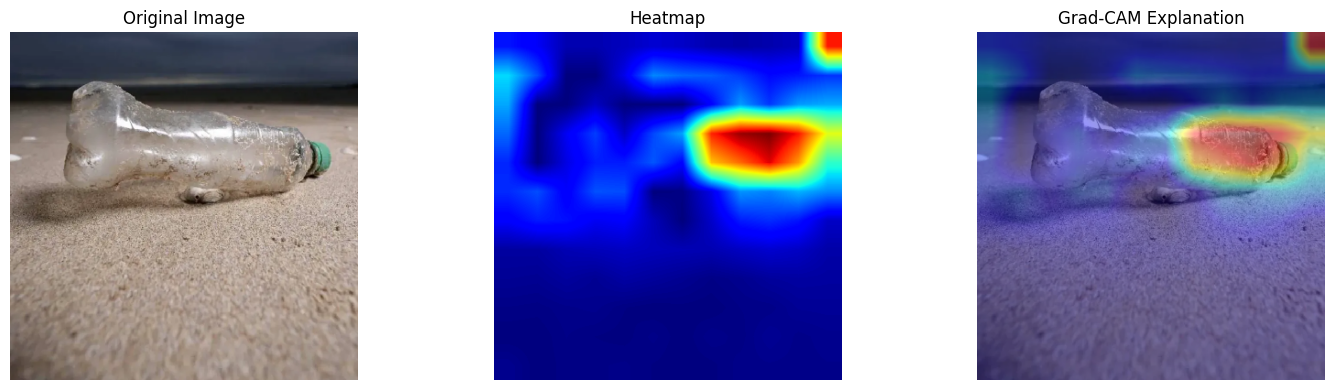

In [12]:
gradcam_final("/content/plasticcwaste.png")

Predicted class: metal waste
Confidence: 0.40938696


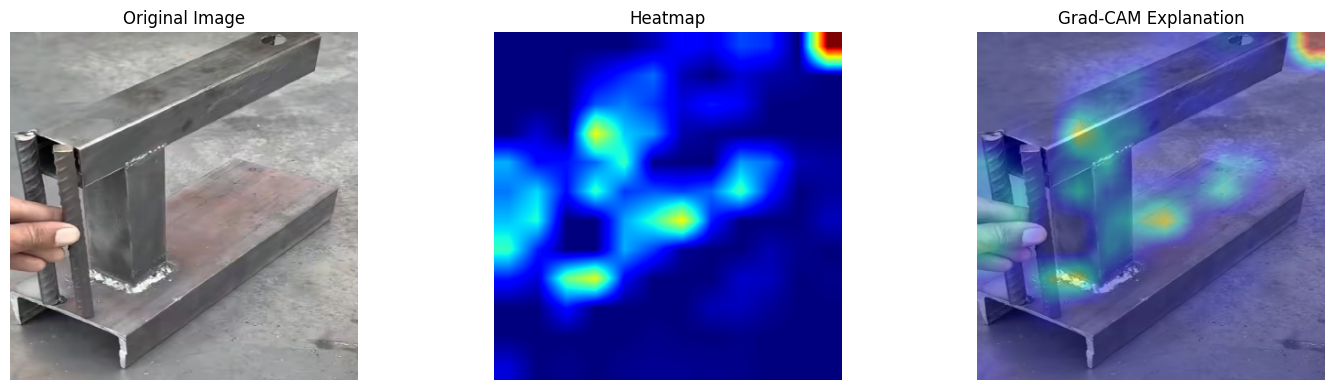

In [ ]:
gradcam_final("/content/sampemetal.jpg")


Predicted class: organic waste
Confidence: 0.7097302


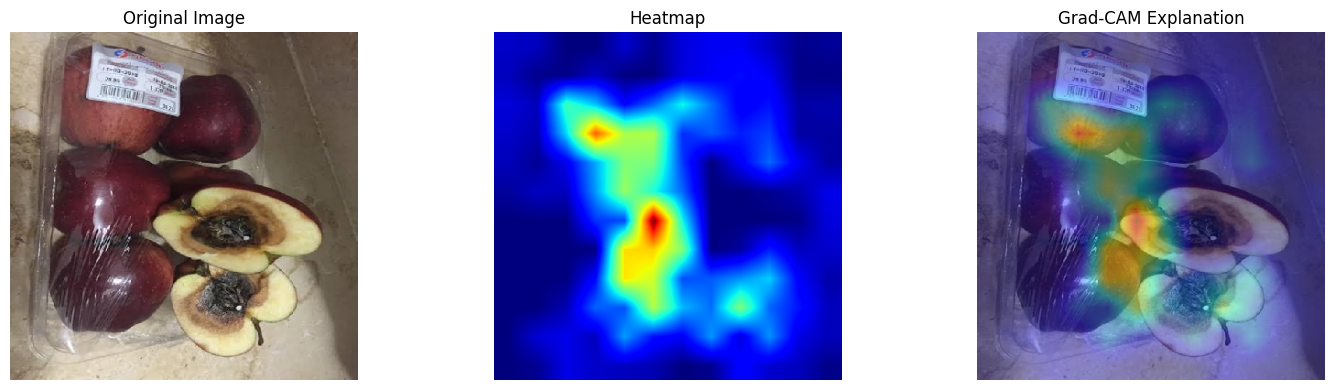

In [ ]:
gradcam_final("/content/sampleorganic.jpg")


Predicted class: paper waste
Confidence: 0.9991698


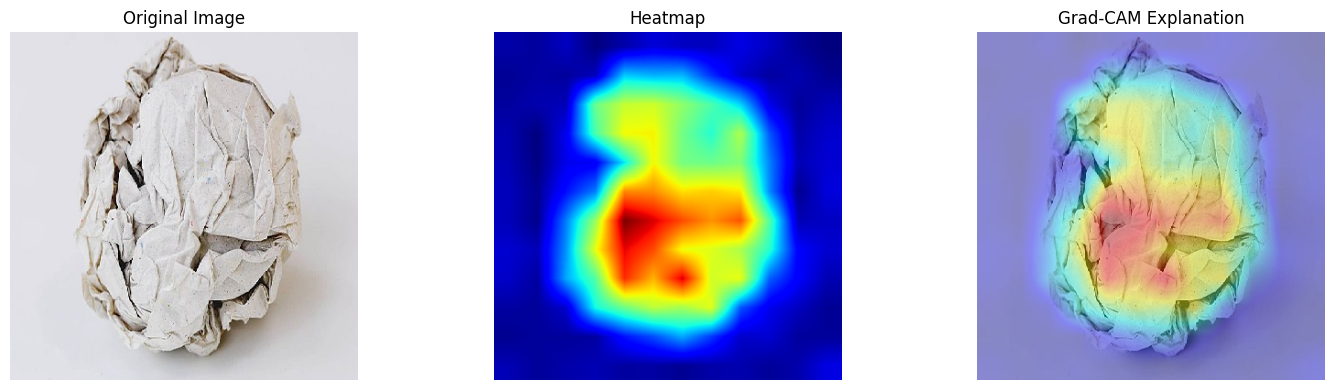

In [ ]:
gradcam_final("/content/samplepaper.jpg")


Predicted class: glass waste
Confidence: 0.5598418


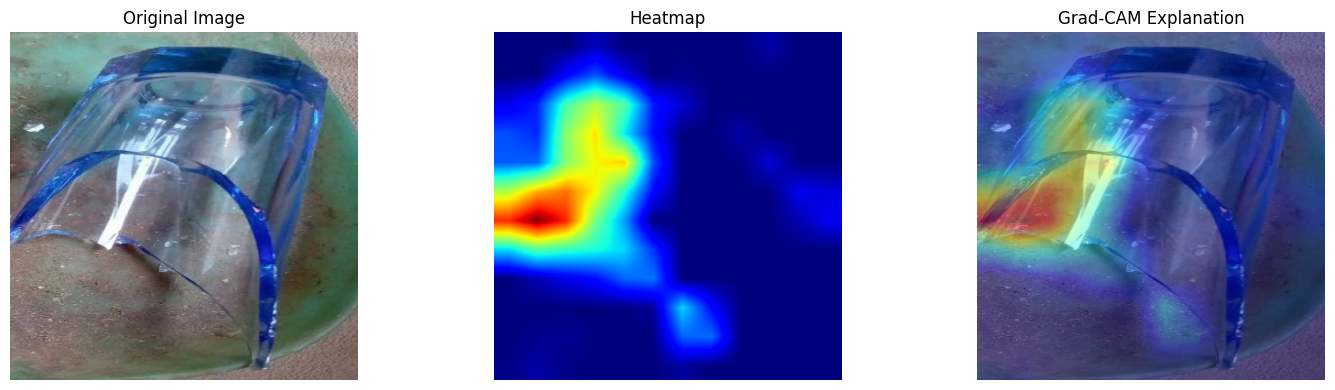

In [ ]:
gradcam_final("/content/sampleglass.jpg")


Predicted class: battery waste
Confidence: 0.865386


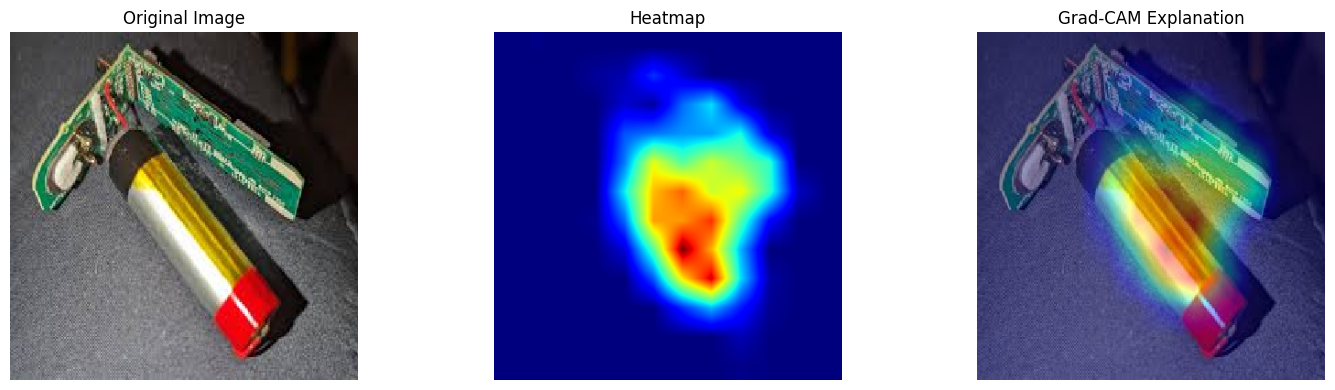

In [ ]:
gradcam_final("/content/samplebattery.jpeg")


Predicted class: E-waste
Confidence: 0.7785415


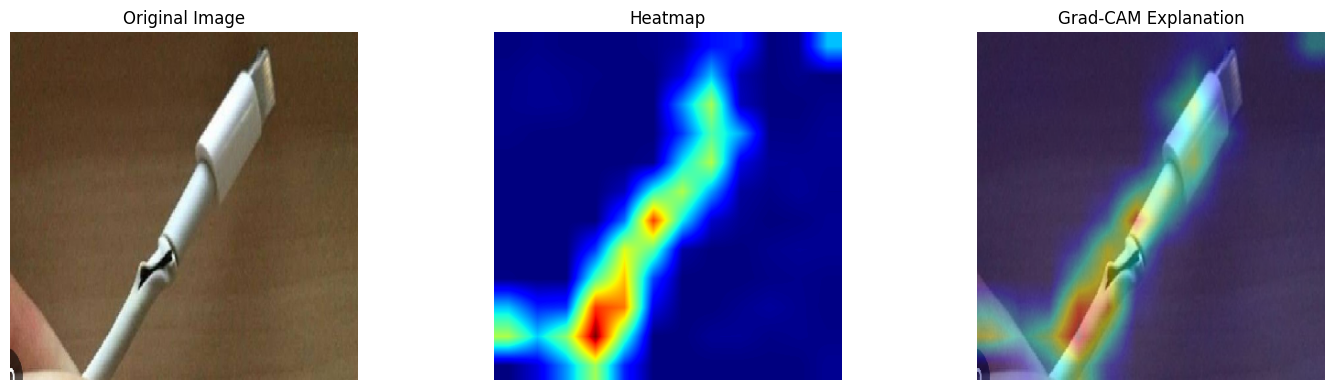

In [ ]:
gradcam_final("/content/sampleewaste.jpeg")


Predicted class: automobile wastes
Confidence: 0.9864182


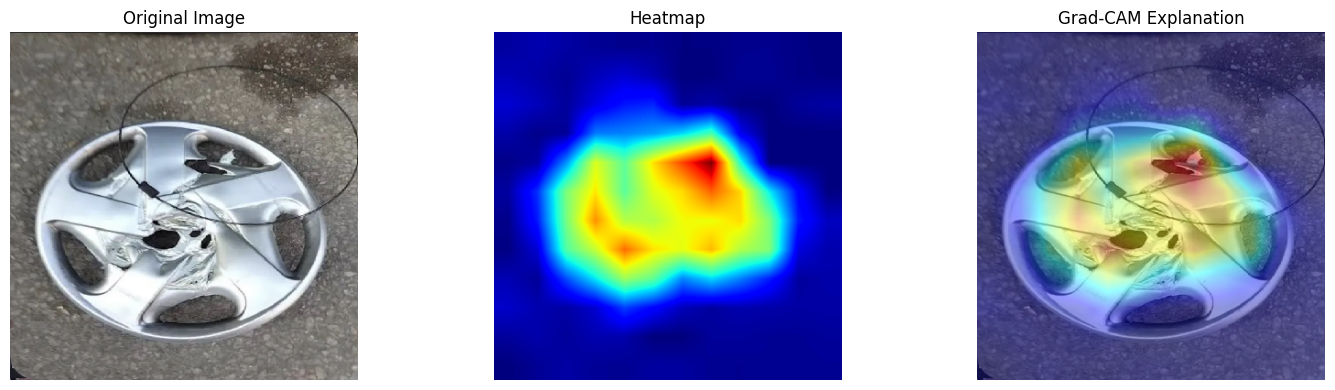

In [6]:
gradcam_final("/content/automobileewaste.png")


Predicted class: light bulbs
Confidence: 0.953413


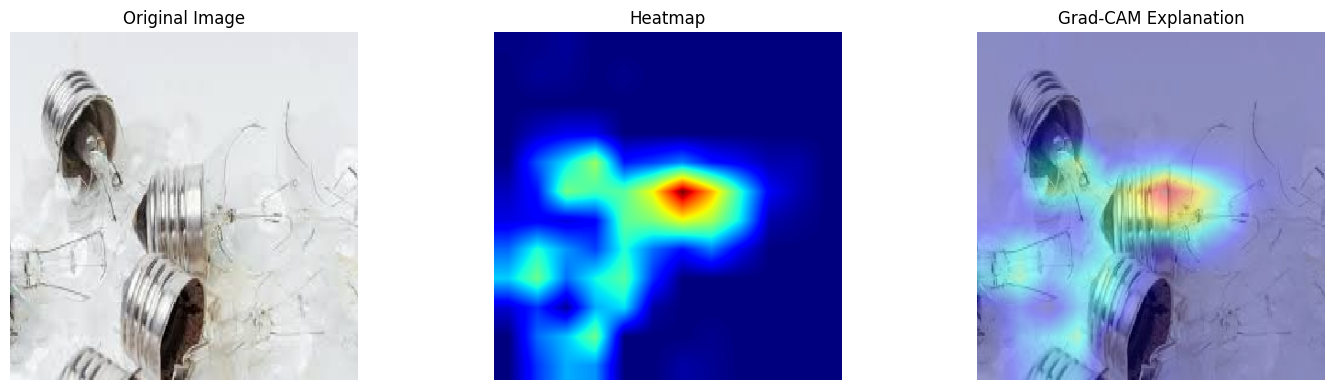

In [ ]:
gradcam_final("/content/samplelightbulb.jpeg")
